<a href="https://colab.research.google.com/github/madhurrathod/nutrition-and-obesity-trends/blob/main/Nutrition_Obesity_Education.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
pip install ucimlrepo

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [35]:

file_path = "/content/drive/MyDrive/Data_Mining_Folder/food_intake/table-3-US-nutrient-intake-and-share-by-food-source.xlsx"


excel_file = pd.ExcelFile(file_path)

df_college = pd.read_excel(file_path, sheet_name='Edu. - College attended')
df_highschool = pd.read_excel(file_path, sheet_name='Edu. - High school degree')
df_less_hs = pd.read_excel(file_path, sheet_name='Edu. - Less than high school')

print(df_college)
print(df_highschool)
print(df_less_hs)


   Table 3F3—Daily nutrient intake and share by food source and education for adults aged 20 and above with college attended, 1989–2018  \
0                                                 NaN                                                                                     
1                                            Nutrient                                                                                     
2                                             Energy                                                                                      
3                                             Energy                                                                                      
4                                             Energy                                                                                      
..                                                ...                                                                                     
83                         

In [36]:
# fetch dataset
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544)

# data (as pandas dataframes)
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets

# metadata
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata)

# variable information
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables)

{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

In [37]:
df_obesity = pd.concat([X, y], axis=1)

display(df_obesity.head())

df_obesity.info()

display(df_obesity.describe())

print(df_obesity['NObeyesdad'].unique())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


In [38]:
def process_usda_sheet(df, education_label):

    target_col_idx = 21

    def get_value(nutrient, source):

        mask = (df.iloc[:, 0].astype(str).str.strip() == nutrient) & \
               (df.iloc[:, 1].astype(str).str.strip() == source)
        row = df[mask]
        if not row.empty:
            return float(row.iloc[0, target_col_idx])
        return 0.0

    return {
        'Education': education_label,
        'Energy_Total': get_value('Energy', 'Total'),
        'Energy_FastFood_Pct': get_value('Energy', 'FAFH: Fast food'),
        'Carbs_Total': get_value('Carbohydrate', 'Total'),
        'Fiber_Total': get_value('Fiber, dietary', 'Total')
    }

education_data = [
    process_usda_sheet(df_college, 'College'),
    process_usda_sheet(df_highschool, 'High School'),
    process_usda_sheet(df_less_hs, 'Less than HS')
]

df_usda_clean = pd.DataFrame(education_data)

df_usda_clean['FastFood_Calories'] = df_usda_clean['Energy_Total'] * (df_usda_clean['Energy_FastFood_Pct'] / 100)

df_usda_clean['Fiber_per_100g_Carbs'] = (df_usda_clean['Fiber_Total'] / df_usda_clean['Carbs_Total']) * 100

display(df_usda_clean)

,Education,Energy_Total,Energy_FastFood_Pct,Carbs_Total,Fiber_Total,FastFood_Calories,Fiber_per_100g_Carbs
0,College,2191.84,15.84,248.54,17.83,347.187456,7.173896
1,High School,2094.26,17.78,243.62,14.67,372.359428,6.021673
2,Less than HS,2107.30,14.25,256.58,17.05,300.290250,6.645101


In [19]:

df_analysis = df_obesity.copy()

obesity_map = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df_analysis['Obesity_Score'] = df_analysis['NObeyesdad'].map(obesity_map)


df_analysis['HighCal_Food_Binary'] = df_analysis['FAVC'].apply(lambda x: 1 if x == 'yes' else 0)


caec_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_analysis['Snack_Freq_Score'] = df_analysis['CAEC'].map(caec_map)

print("Preprocessing complete. Checking correlations with Obesity Score...")
correlations = df_analysis[['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'HighCal_Food_Binary', 'Obesity_Score']].corr()['Obesity_Score']
print(correlations.sort_values(ascending=False))

Preprocessing complete. Checking correlations with Obesity Score...
Obesity_Score          1.000000
HighCal_Food_Binary    0.247793
FCVC                   0.227759
CH2O                   0.133008
NCP                    0.026690
TUE                   -0.107991
FAF                   -0.199901
Name: Obesity_Score, dtype: float64


In [20]:

high_cal_consumers = df_analysis[df_analysis['HighCal_Food_Binary'] == 1].copy()

high_cal_consumers['Veggie_Group'] = high_cal_consumers['FCVC'].round().astype(int)

veggie_impact = high_cal_consumers.groupby('Veggie_Group')['Obesity_Score'].mean()

print("Impact of Vegetable Intake on Obesity among High-Calorie Consumers:")
print(veggie_impact)

Impact of Vegetable Intake on Obesity among High-Calorie Consumers:
Veggie_Group
1    2.479167
2    2.858259
3    3.822654
Name: Obesity_Score, dtype: float64


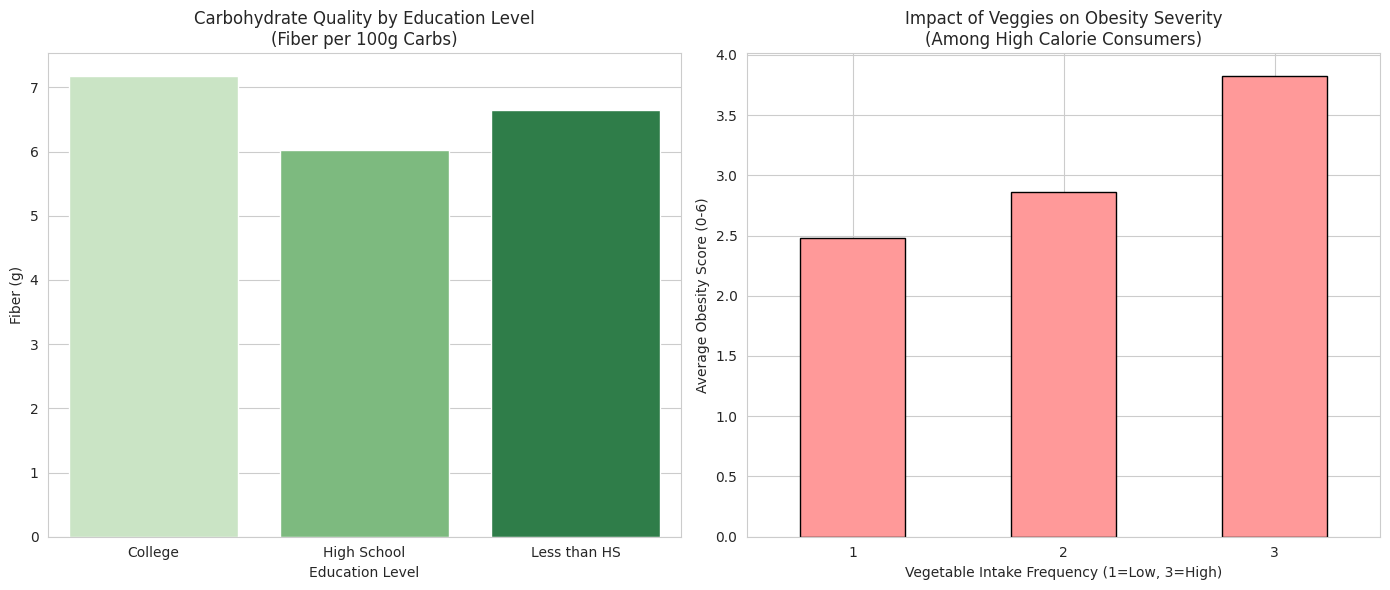

In [21]:
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.barplot(x='Education', y='Fiber_per_100g_Carbs', data=df_usda_clean, palette='Greens')
plt.title('Carbohydrate Quality by Education Level\n(Fiber per 100g Carbs)')
plt.ylabel('Fiber (g)')
plt.xlabel('Education Level')

plt.subplot(1, 2, 2)
veggie_impact.plot(kind='bar', color='#ff9999', edgecolor='black')
plt.title('Impact of Veggies on Obesity Severity\n(Among High Calorie Consumers)')
plt.ylabel('Average Obesity Score (0-6)')
plt.xlabel('Vegetable Intake Frequency (1=Low, 3=High)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [39]:

features = ['HighCal_Food_Binary', 'NCP', 'Snack_Freq_Score', 'FCVC']
feature_names = ['High Calorie Src', 'Meal Count', 'Snacking Freq', 'Veggie Freq']

X_tree = df_analysis[features]
y_tree = df_analysis['NObeyesdad']


clf_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_tree.fit(X_tree, y_tree)


X_cluster = df_usda_clean[['Energy_Total', 'FastFood_Calories']]


scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)


kmeans = KMeans(n_clusters=3, random_state=42)
df_usda_clean['Cluster'] = kmeans.fit_predict(X_cluster_scaled)


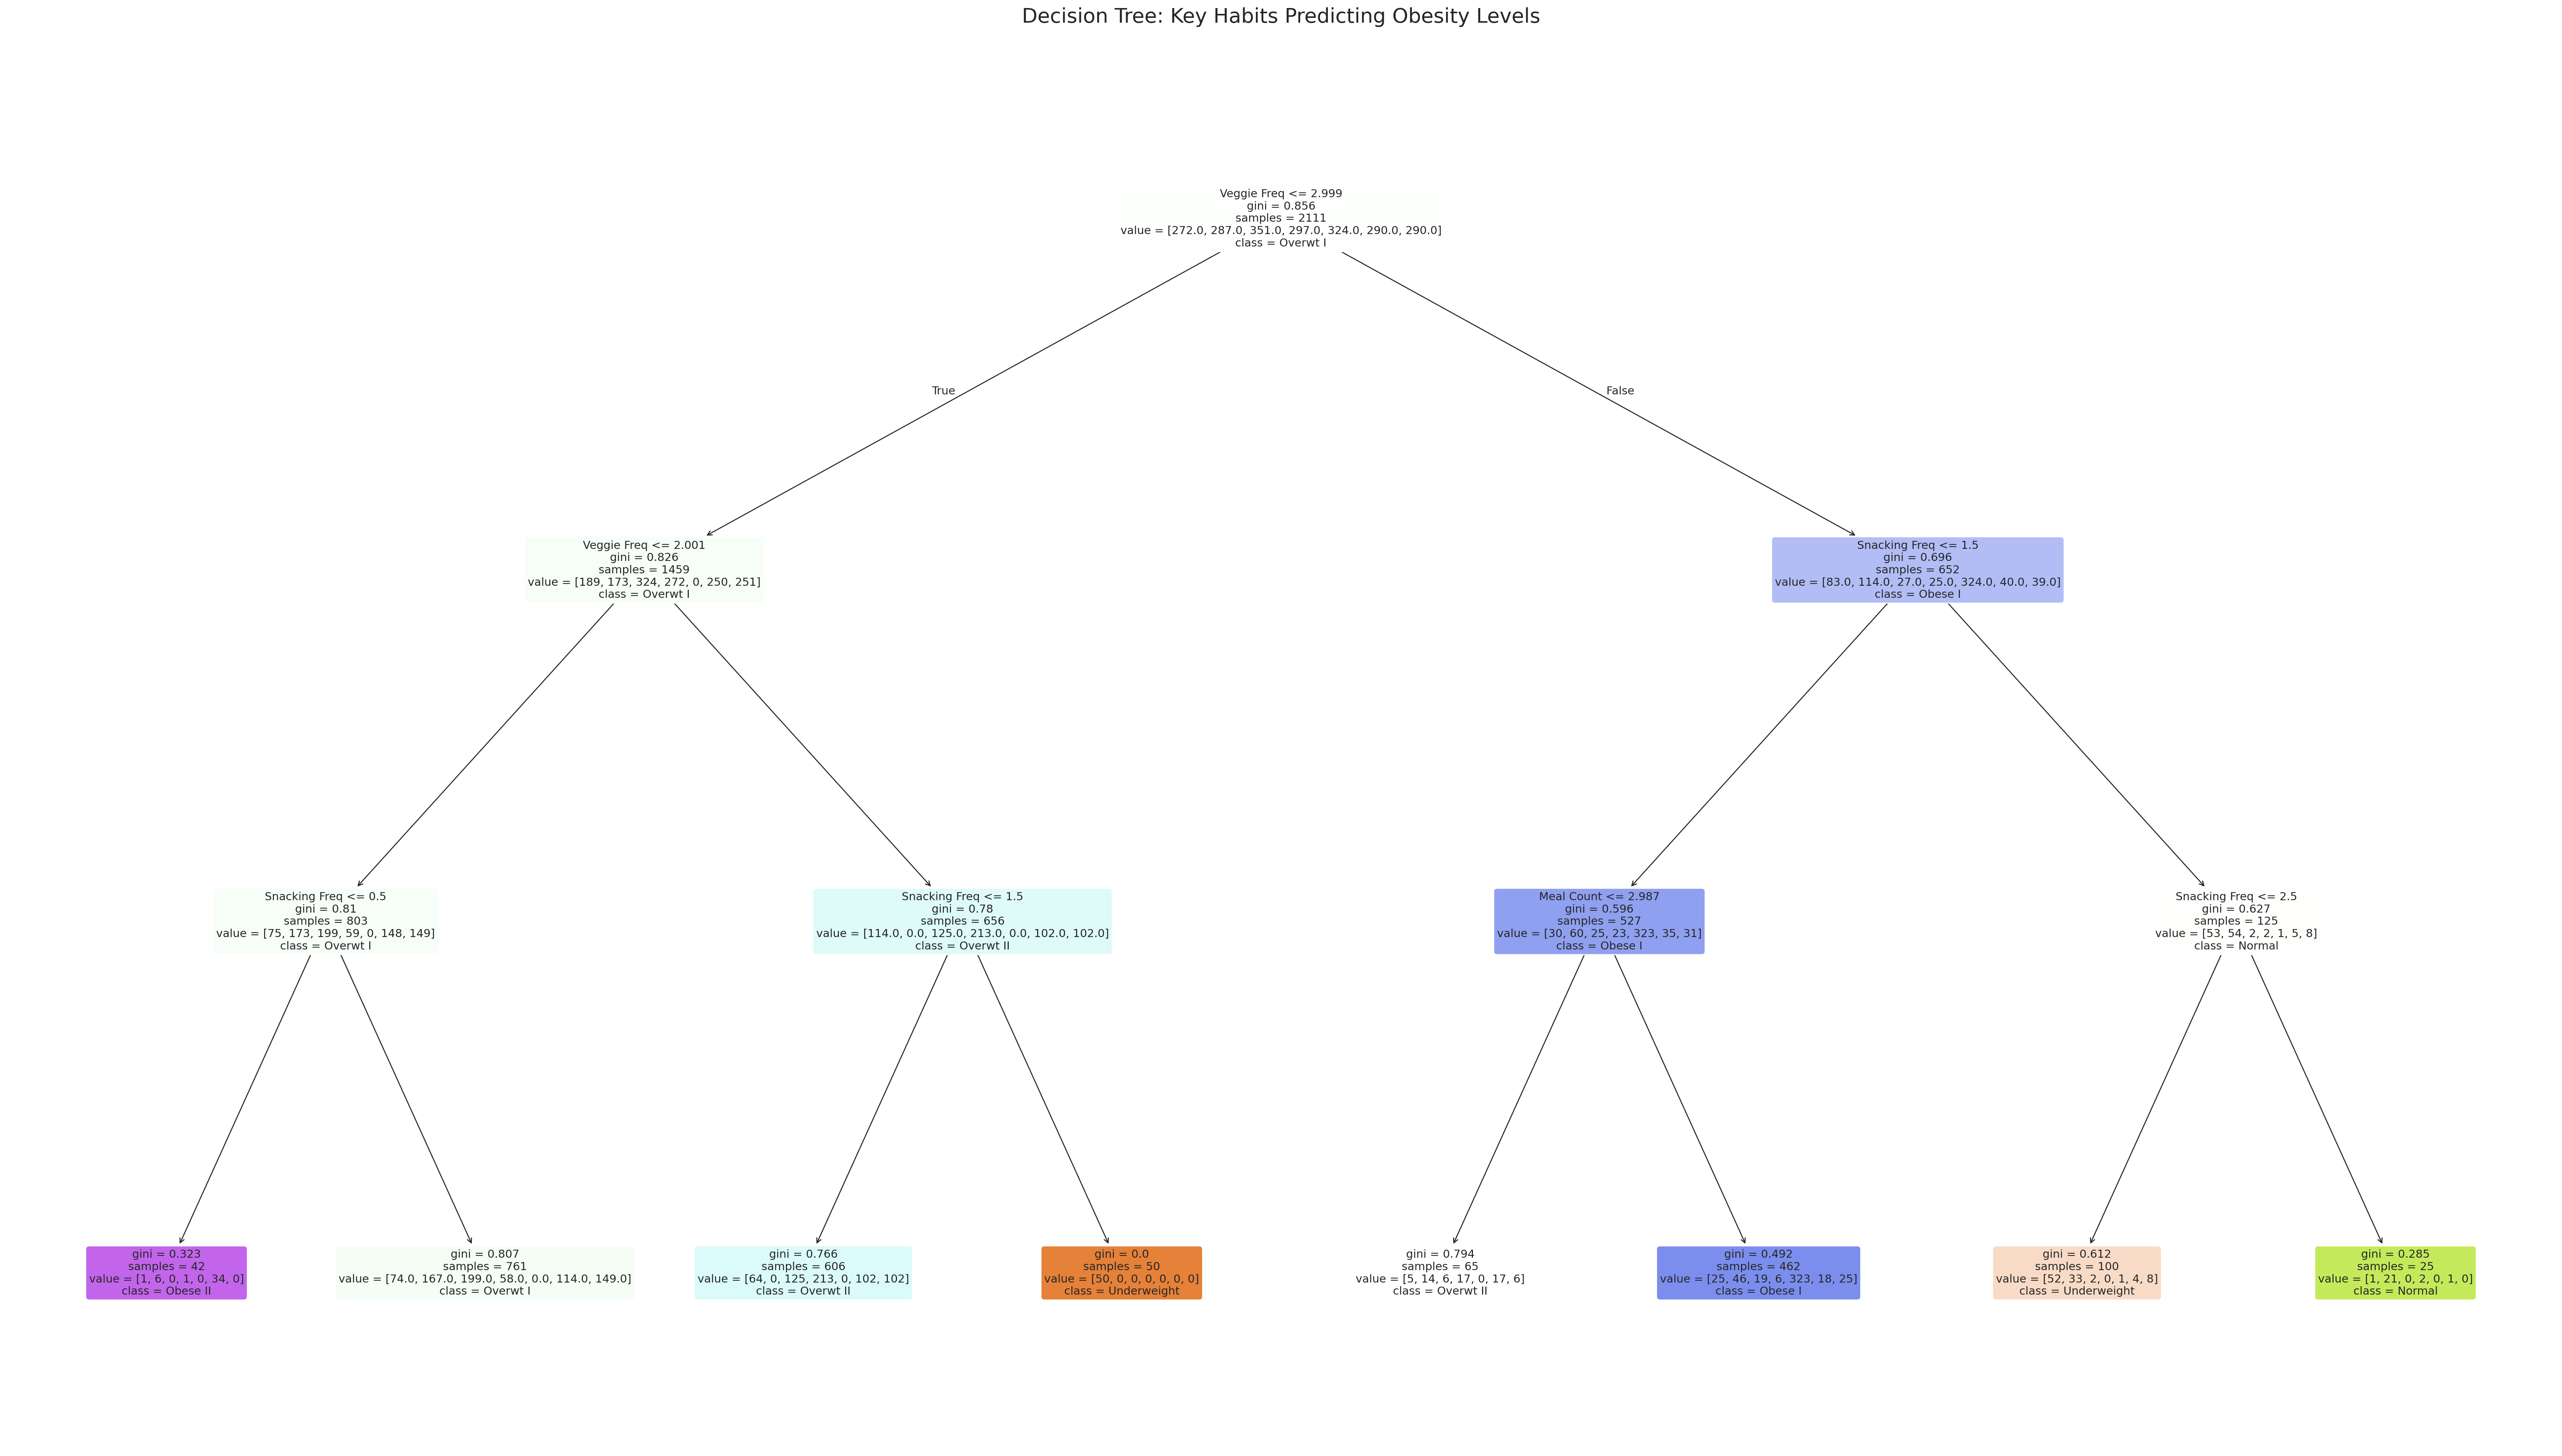

In [41]:

plt.figure(figsize=(45, 25), dpi=200)

clean_class_names = [
    'Underweight', 'Normal',
    'Overwt I', 'Overwt II',
    'Obese I', 'Obese II', 'Obese III'
]

# Plot the tree
plot_tree(clf_tree,
          feature_names=feature_names,
          class_names=clean_class_names,
          filled=True,        # Colors nodes by majority class
          rounded=True,       # Rounds corners for a modern look
          fontsize=11,        # Size appropriate for the figure width
          impurity=True,     # Hides 'gini' score to save vertical space
          proportion=False,   # Shows actual sample counts
          precision=3)        # Keeps decimal places tidy

plt.title('Decision Tree: Key Habits Predicting Obesity Levels', fontsize=20, pad=20)
plt.show()

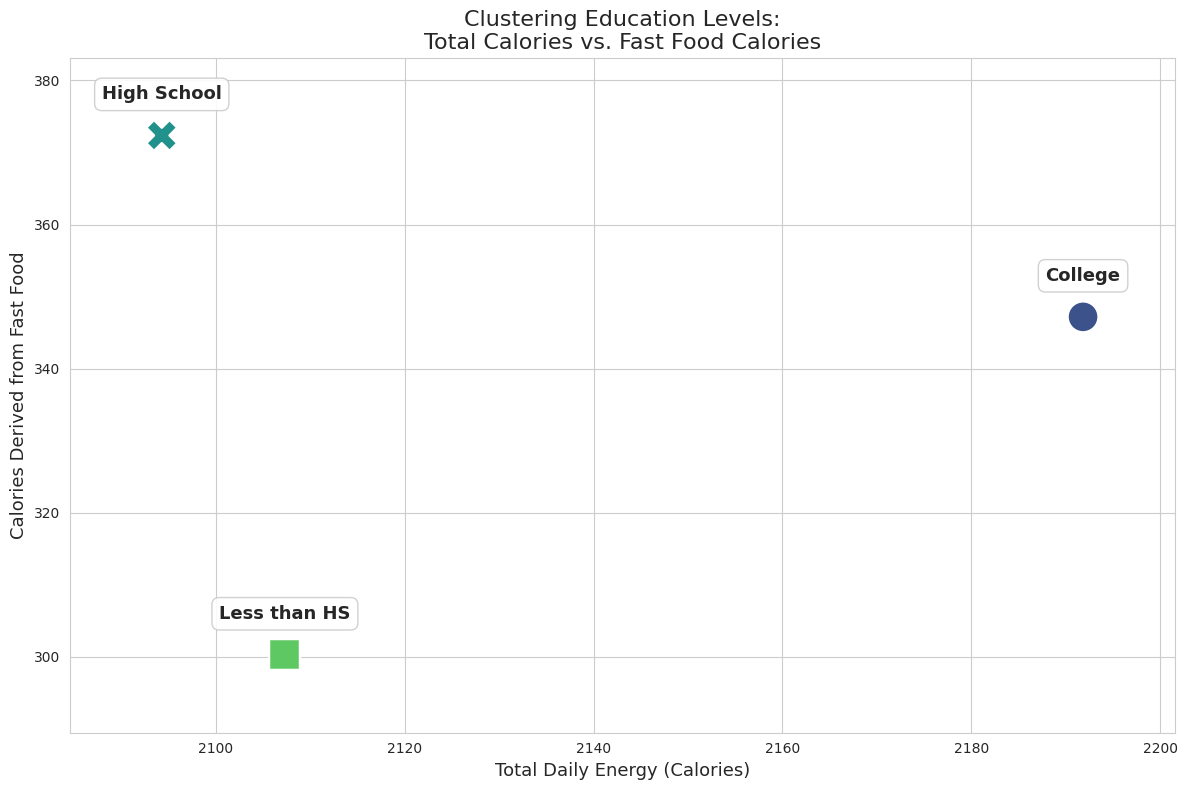

In [44]:

plt.figure(figsize=(12, 8), dpi=100)

markers = {'College': 'o', 'High School': 'X', 'Less than HS': 's'}

sns.scatterplot(x='Energy_Total',
                y='FastFood_Calories',
                data=df_usda_clean,
                hue='Education',
                style='Education',
                markers=markers,
                s=500,
                palette='viridis',
                legend=False)


for i in range(df_usda_clean.shape[0]):
    x_val = df_usda_clean.Energy_Total.iloc[i]
    y_val = df_usda_clean.FastFood_Calories.iloc[i]
    label = df_usda_clean.Education.iloc[i]

    plt.text(x=x_val,
             y=y_val + 5,
             s=label,
             fontsize=13,
             fontweight='bold',
             ha='center',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cccccc', boxstyle='round,pad=0.4'))

plt.title('Clustering Education Levels:\nTotal Calories vs. Fast Food Calories', fontsize=16)
plt.xlabel('Total Daily Energy (Calories)', fontsize=13)
plt.ylabel('Calories Derived from Fast Food', fontsize=13)

plt.margins(y=0.15, x=0.1)

plt.tight_layout()
plt.show()